<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import matplotlib.pyplot as plt



In [12]:
df = pd.read_csv("wch356_project_summary.csv", sep=";", header=None)
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,stineb_mct,00103d05f1291a1acf567cbd3f18cb60355096de,autodocs <autodocs>,1528883833,build based on 07d0d25\r\n,2018-06
1,stineb_mct,00205d9769d1eebf71c061df26c48c30badfbd8a,Kristoffer Carlsson <kcarlsson89@gmail.com>,1534505613,fixes for the display system\r\n,2018-08
2,stineb_mct,007c35740b47d823f6c8604ceecdf630f2e5f40a,Documenter.jl <documenter@juliadocs.github.io>,1707723004,build based on 3e224d5\r\n,2024-02
3,stineb_mct,0126d3f46b1b77542c56121a29150387327f4648,Kristoffer Carlsson <kcarlsson89@gmail.com>,1521891456,add ... example in options section\r\n,2018-03
4,stineb_mct,01c54eda7d7fbfa1f80a50f109d20e1d0853573e,Jerome Guterl <guterlj@fusion.gat.com>,1707746651,Merge c754a315c5f6fe884f98e969a6736d7b087871a6...,2024-02


In [13]:
prj='stineb_mct'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
monthly_counts[['Month','Commits']].rename(columns={'Commits':'#Commits'}).to_csv('wch356_commits_timeseries_'+prj+'.csv', sep=';', index=False)


In [14]:
print(len(df1))
print(df['project'].unique())

72403
<StringArray>
[                     'stineb_mct',        'kristofferc_pgfplotsx.jl',
             'fizban007_coffeegpu',               'clayne_retrowrite',
             'dkazanc_tomophantom',            'alicevision_meshroom',
 'fmidev_smartmet-library-newbase',                     'knausb_vcfr',
                  'fedml-ai_fedml',             'latte-central_latte']
Length: 10, dtype: str


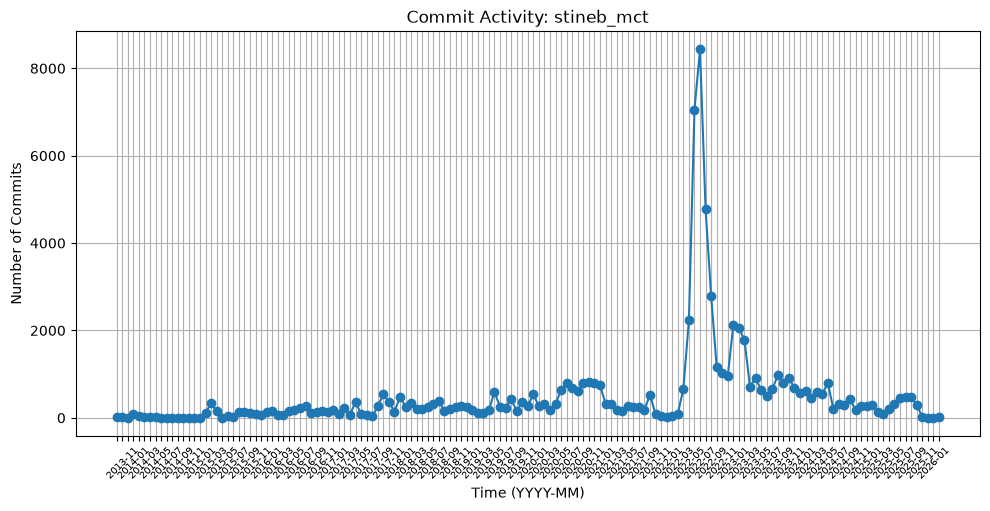

In [15]:
# Plot
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("wch356_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv

In [16]:
projects = ['kristofferc_pgfplotsx.jl', 'fizban007_coffeegpu', 'clayne_retrowrite',
            'dkazanc_tomophantom', 'alicevision_meshroom', 'fmidev_smartmet-library-newbase',
            'knausb_vcfr', 'fedml-ai_fedml', 'latte-central_latte', 'stineb_mct']

# Fill in from GitHub: [stars, forks, last commit date]
github = {p: [None, None, None] for p in projects}
# github['stineb_mct'] = [12, 3, '2024-02-18']   <- example format

# Fill in after looking at your charts: steady, rising, declining, U-shaped, cyclical, irregular
pattern = {p: None for p in projects}
pattern['dkazanc_tomophantom'] = 'declining'
pattern['fedml-ai_fedml'] = 'irregular'
pattern['fizban007_coffeegpu'] = 'irregular'
pattern['fmidev_smartmet-library-newbase'] = 'declining'
pattern['knausb_vcfr'] = 'irregular'
pattern['kristofferc_pgfplotsx.jl'] = 'declining'
pattern['latte-central_latte'] = 'cyclical'
pattern['stineb_mct'] = 'irregular'
pattern['alicevision_meshroom'] = 'rising'
pattern['clayne_retrowrite'] = 'cyclical'

stats = []
for prj in projects:
    ts = pd.read_csv('wch356_commits_timeseries_'+prj+'.csv', sep=';')
    g = df[df['project']==prj]
    vals = ts['#Commits'].tolist()

    # find every stretch of zero-commit months
    runs, i = [], 0
    while i < len(vals):
        if vals[i] == 0:
            j = i
            while j < len(vals) and vals[j] == 0:
                j += 1
            runs.append((i, j - i))
            i = j
        else:
            i += 1

    if runs:
        s, length = max(runs, key=lambda r: r[1])
        gap_start, gap_end = ts['Month'][s], ts['Month'][s+length-1]
        after = int(sum(vals[s+length:]))
    else:
        gap_start, gap_end, length, after = None, None, 0, int(sum(vals))

    times = pd.to_datetime(g['time'], unit='s')
    stats.append({
        'project': prj,
        'number of commits': g['commit'].nunique(),
        'number of authors': g['author'].nunique(),
        'max time': times.max().strftime('%Y-%m-%d'),
        'min time': times.min().strftime('%Y-%m-%d'),
        'number of stars': github[prj][0],
        'number of forks': github[prj][1],
        'last commit date': github[prj][2],
        'LongestGapStart': gap_start,
        'LongestGapEnd': gap_end,
        'LongestGapLength': length,
        'NumCommitsAfterLastGap': after,
        'NumberOfGapsInTimeline': sum(1 for _, l in runs if l >= 3),
        'ActivityPattern': pattern[prj],
    })

stats = pd.DataFrame(stats)
stats.to_csv('wch356_project_stats.csv', index=False)
stats

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,kristofferc_pgfplotsx.jl,1145,63,2025-10-06,2017-05-05,None,None,None,2025-05,2025-09,5,19,5,None
1,fizban007_coffeegpu,688,14,2025-02-20,2019-06-07,None,None,None,2024-02,2025-01,12,1,4,None
2,clayne_retrowrite,373,15,2025-04-26,2018-08-29,None,None,None,2024-06,2025-03,10,3,4,None
3,dkazanc_tomophantom,441,19,2025-04-02,2017-07-01,None,None,None,2022-11,2023-08,10,33,4,None
4,alicevision_meshroom,7062,142,2025-11-04,2015-06-13,None,None,None,2017-01,2017-02,2,6661,0,None
5,fmidev_smartmet-library-newbase,1360,29,2025-10-28,2016-12-01,None,None,None,2025-04,2025-05,2,7,0,None
6,knausb_vcfr,1539,26,2026-02-23,2013-10-28,None,None,None,2020-11,2021-07,9,71,8,None
7,fedml-ai_fedml,22540,187,2025-10-28,2020-07-22,None,None,None,2022-01,2022-02,2,20744,0,None
8,latte-central_latte,488,16,2025-03-13,2015-03-04,None,None,None,2021-02,2022-10,21,27,9,None
9,stineb_mct,36013,517,2026-02-23,2013-10-28,None,None,None,2014-10,2014-12,3,72159,1,None
